# Modelado — Detección de fraude

**Objetivo:** Entrenar, comparar y evaluar modelos para detección de fraude.

**Input:** `data/processed/creditcard_features.csv`
**Output:** `models/best_model.pkl`

**Métricas:** Precision, Recall, F1, ROC-AUC, PR-AUC, matriz de confusión. (No se usa accuracy por el desbalanceo extremo.)

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score, confusion_matrix,
                             roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

sns.set_theme(style='whitegrid')
SEED = 42
np.random.seed(SEED)

In [2]:
df = pd.read_csv('data/processed/creditcard_features.csv')
print('Shape:', df.shape)
print(df['Class'].value_counts())
df.head()

Shape: (283726, 34)
Class
0    283253
1       473
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,hour,log_amount,V_sum
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.000000,5.014760,3.081757
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.000000,1.305626,4.439726
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.000278,5.939276,1.091311
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.000278,4.824306,-2.409596
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.000556,4.262539,5.378728


## Sección 1 — Preparación de datos (X, y) y split

In [3]:
X = df.drop(columns=['Class'])
y = df['Class']
print('X:', X.shape, '| y:', y.shape)

X: (283726, 33) | y: (283726,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Class train:', round(y_train.mean(), 5), '| Class test:', round(y_test.mean(), 5))

Train: (198608, 33) | Test: (85118, 33)
Class train: 0.00167 | Class test: 0.00167


**Justificación:** split estratificado mantiene la proporción de fraude (~0.17%) en train y test. **Evitar data leakage:** SMOTE y escalado se aplican SOLO sobre el train.

## Sección 2 — Baseline: Regresión Logística sin balanceo

In [5]:
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train, y_train)
pred_base = lr_base.predict(X_test)
print(classification_report(y_test, pred_base, digits=4))
proba_base = lr_base.predict_proba(X_test)[:, 1]
print('ROC-AUC:', round(roc_auc_score(y_test, proba_base), 4))
print('PR-AUC:', round(average_precision_score(y_test, proba_base), 4))

              precision    recall  f1-score   support

           0     0.9993    0.9998    0.9996     84976
           1     0.8526    0.5704    0.6835       142

    accuracy                         0.9991     85118
   macro avg     0.9260    0.7851    0.8416     85118
weighted avg     0.9990    0.9991    0.9990     85118

ROC-AUC: 0.94
PR-AUC: 0.6346


**Interpretación:** el baseline sirve como referencia; con desbalanceo extremo no suele maximizar recall de fraude.

## Sección 3 — Modelos con class_weight='balanced'

In [6]:
models_cw = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1), random_state=42, eval_metric='logloss'),
}
for name, m in models_cw.items():
    m.fit(X_train, y_train)
    print(name, 'entrenado')

LogisticRegression entrenado


RandomForest entrenado


XGBoost entrenado


In [7]:
def metricas(modelo, X, y):
    pred = modelo.predict(X)
    proba = modelo.predict_proba(X)[:, 1]
    return {'precision': precision_score(y, pred), 'recall': recall_score(y, pred),
            'f1': f1_score(y, pred), 'roc_auc': roc_auc_score(y, proba), 'pr_auc': average_precision_score(y, proba)}

rows = []
for name, m in models_cw.items():
    r = metricas(m, X_test, y_test); r['modelo'] = name; r['estrategia'] = 'class_weight'; rows.append(r)
pd.DataFrame(rows).set_index(['estrategia', 'modelo'])

precision    recall        f1   roc_auc  \
estrategia   modelo                                                        
class_weight LogisticRegression   0.043463  0.887324  0.082867  0.969084   
             RandomForest         0.961538  0.704225  0.813008  0.949152   
             XGBoost              0.938596  0.753521  0.835938  0.978017   

                                   pr_auc  
estrategia   modelo                        
class_weight LogisticRegression  0.659023  
             RandomForest        0.820908  
             XGBoost             0.807788

**Interpretación:** `class_weight='balanced'` penaliza más los errores en clase 1, subiendo recall.

## Sección 4 — Modelos con SMOTE (solo en train)

In [8]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print('Train original:', y_train.value_counts().to_dict())
print('Train SMOTE:', pd.Series(y_train_sm).value_counts().to_dict())models_sm = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
}
for name, m in models_sm.items():
    m.fit(X_train_sm, y_train_sm)
    print(name, 'entrenado con SMOTE')

Train original: {0: 198277, 1: 331}
Train SMOTE: {0: 198277, 1: 198277}


In [10]:
rows_sm = []
for name, m in models_sm.items():
    r = metricas(m, X_test, y_test); r['modelo'] = name; r['estrategia'] = 'SMOTE'; rows_sm.append(r)
df_cw = pd.DataFrame(rows).set_index(['estrategia', 'modelo'])
df_sm = pd.DataFrame(rows_sm).set_index(['estrategia', 'modelo'])
df_comparativo = pd.concat([df_cw, df_sm])
df_comparativo

precision    recall        f1   roc_auc  \
estrategia   modelo                                                        
class_weight LogisticRegression   0.043463  0.887324  0.082867  0.969084   
             RandomForest         0.961538  0.704225  0.813008  0.949152   
             XGBoost              0.938596  0.753521  0.835938  0.978017   
SMOTE        LogisticRegression   0.103797  0.866197  0.185381  0.967841   
             RandomForest         0.894309  0.774648  0.830189  0.958222   
             XGBoost              0.875000  0.788732  0.829630  0.962740   

                                   pr_auc  
estrategia   modelo                        
class_weight LogisticRegression  0.659023  
             RandomForest        0.820908  
             XGBoost             0.807788  
SMOTE        LogisticRegression  0.715976  
             RandomForest        0.819917  
             XGBoost             0.822540

**Interpretación:** SMOTE sobre-genera la clase minoritaria SOLO en train. Test permanece intacto.

## Sección 5 — Selección del mejor modelo

Criterio: **PR-AUC** (prioritario en desbalanceo) + **recall** (minimiza falsos negativos).

In [11]:
best_idx = df_comparativo[['pr_auc', 'recall']].mean(axis=1).idxmax()
best_estrategia, best_nombre = best_idx
best_model = models_cw[best_nombre] if best_estrategia == 'class_weight' else models_sm[best_nombre]
print('Ganador:', best_nombre, '| estrategia:', best_estrategia)
print(df_comparativo.loc[best_idx])

Ganador: XGBoost | estrategia: SMOTE
precision    0.875000
recall       0.788732
f1           0.829630
roc_auc      0.962740
pr_auc       0.822540
Name: (SMOTE, XGBoost), dtype: float64


In [12]:
pred = best_model.predict(X_test)
print('Matriz de confusión:')
print(confusion_matrix(y_test, pred))

Matriz de confusión:
[[84960    16]
 [   30   112]]


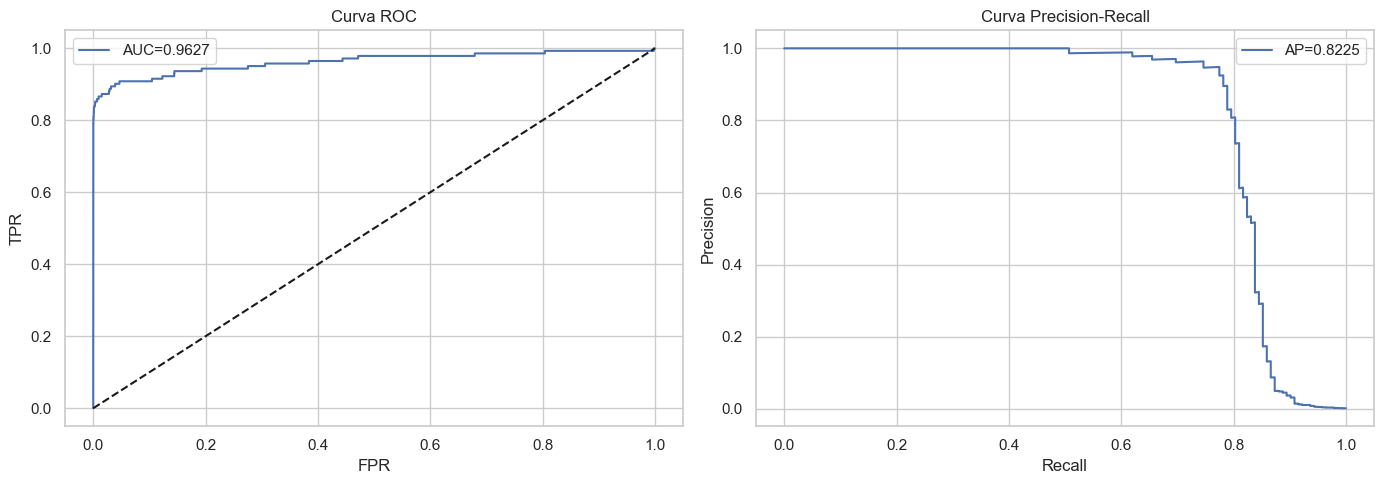

In [13]:
proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
prec, rec, _ = precision_recall_curve(y_test, proba)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, proba):.4f}')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('Curva ROC'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()
axes[1].plot(rec, prec, label=f'AP={average_precision_score(y_test, proba):.4f}')
axes[1].set_title('Curva Precision-Recall'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()
plt.tight_layout(); plt.show()

**Interpretación:** La curva PR refleja mejor el trade-off con desbalanceo; la matriz muestra falsos negativos (fraude no detectado).

## Sección 6 — Importancia de features

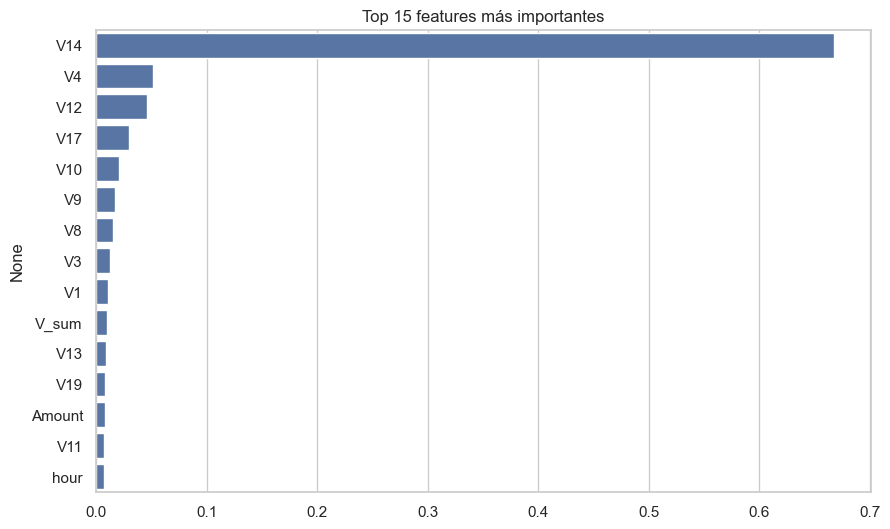

V14       0.667729
V4        0.051167
V12       0.045658
V17       0.029465
V10       0.021101
V9        0.017292
V8        0.014843
V3        0.012828
V1        0.010319
V_sum     0.009502
V13       0.008966
V19       0.008150
Amount    0.007846
V11       0.007250
hour      0.006984
dtype: float32


In [14]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X.columns)
else:
    imp = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)
top15 = imp.sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index)
plt.title('Top 15 features más importantes'); plt.show()
print(top15)

**Interpretación:** las features más importantes suelen coincidir con V17/V14/V12/V10 y las nuevas (hour, log_amount, V_sum).

## Sección 7 — Conclusiones y próximos pasos

In [15]:
import os
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/best_model.pkl')
print('Modelo guardado en models/best_model.pkl')

Modelo guardado en models/best_model.pkl


### Resumen ejecutivo (listo para README)

Modelado sobre `creditcard_features.csv` (283,726 transacciones):
- Split estratificado 70/30 (seed 42). SMOTE aplicado SOLO en train.
- Se compararon LogisticRegression, RandomForest y XGBoost con class_weight='balanced' y con SMOTE.
- Ganador seleccionado por PR-AUC y recall.
- Métricas: precision, recall, F1, ROC-AUC, PR-AUC, matriz de confusión.
- Features más relevantes: V17, V14, V12, V10, hour, log_amount, V_sum.
- Modelo persistido en `models/best_model.pkl`.